In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from scipy.stats import fisher_exact
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from statsmodels.stats.multitest import multipletests

from seq_utils import (
    AA_ORDER, AA_INDEX, BLOSUM62, BLOSUM62_SELFSCORES,
    variable_positions, hamming_distance_matrix, blosum62_similarity_matrix,
)


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
FEAT_TABLE_BASE = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models"
FEAT_TABLE      = os.path.join(FEAT_TABLE_BASE, "feat_table_500ns.xlsx")
REPO_DIR        = "/Users/ivanatang/Developer/biosensors"
MD_CANDIDATE_GUIDE = os.path.join(REPO_DIR, "md_candidate_guide.csv")

# ── seq_source cohort filter ────────────────────────────────────────────────
# "all" trains/tests on the full assembled cohort. "ngs_observed" restricts to
# sequences whose md_candidate_guide.csv `source` == "ngs_observed" (sequencing-
# confirmed designs via Y2H/FACS sort-seq; depth>=10, P_bind/P_const thresholds),
# excluding "designed_assumed" candidates that only passed computational
# structure-prediction QC with no experimental confirmation. Legacy
# seq*_binder/seq*_nb sequences predate md_candidate_guide.csv and have no
# source entry -- excluded from "ngs_observed" (provenance unconfirmed) but
# retained under "all". Mirrors the filter in ML_classification.ipynb.
SEQ_SOURCE = "ngs_observed"   # "all" | "ngs_observed"

MD_GROUP_SUFFIX = {
    "binder":              "_binder",
    "non_binder":          "_nb",
    "negative_low_pocket": "_low_pkt",
    "negative_fail_gate":  "_fail_gate",
}

OUT_DIR = os.path.join(REPO_DIR, "sequence_similarity", SEQ_SOURCE)
os.makedirs(OUT_DIR, exist_ok=True)

BINARY_LABEL = {
    "binder":    1,
    "nonbinder": 0,
    "low_pkt":   0,
    "fail_gate": 0,
}
DISPLAY_LABEL = {
    "binder":    "Binder",
    "nonbinder": "False Positive",
    "low_pkt":   "Low Confidence",
    "fail_gate": "Fail Geometry",
}
GROUP_COLORS = {
    "binder":    "#648FFF",
    "nonbinder": "#DC267F",
    "low_pkt":   "#FE6100",
    "fail_gate": "#FFB000",
}


In [3]:
# ── Data loader ────────────────────────────────────────────────────────────────

def load_feat_table(path, seq_source=SEQ_SOURCE):
    df = pd.read_excel(path, sheet_name="all_feats_500ns")
    df.columns = df.columns.str.strip()
    rename = {}
    for col in df.columns:
        if col.lower() == "sequence": rename[col] = "sequence"
        if col.lower() == "group":    rename[col] = "group"
        if col.lower() == "name":     rename[col] = "name"
    df = df.rename(columns=rename)
    df["group"]    = df["group"].astype(str).str.strip().str.lower()
    df["sequence"] = df["sequence"].astype(str).str.strip()
    df = df[df["group"].isin(BINARY_LABEL)].reset_index(drop=True)
    df = df[df["sequence"].str.len() > 0].reset_index(drop=True)
    n_base = len(df)

    # ── seq_source cohort filter (see SEQ_SOURCE comment in the paths cell) ──
    mcg = pd.read_csv(MD_CANDIDATE_GUIDE)
    mcg["name"] = mcg["pair_id"].astype(str) + mcg["md_group"].map(MD_GROUP_SUFFIX)
    df = df.merge(mcg[["name", "source"]], on="name", how="left")
    n_no_source = int(df["source"].isna().sum())
    print(f"  seq_source coverage : {n_base - n_no_source}/{n_base} matched to md_candidate_guide.csv "
          f"({n_no_source} legacy/unlisted -> source unknown)")

    if seq_source == "ngs_observed":
        df = df[df["source"] == "ngs_observed"].reset_index(drop=True)
    elif seq_source != "all":
        raise ValueError(f"Unknown seq_source={seq_source!r}, expected 'all' or 'ngs_observed'")

    print(f"Loaded {len(df)} sequences (seq_source={seq_source!r}).")
    print(df["group"].value_counts().to_string())
    return df


# variable_positions, hamming_distance_matrix, blosum62_similarity_matrix
# now live in seq_utils.py (shared with ML_classification.ipynb for
# sequence-similarity-based GroupKFold CV grouping).


# ── 3. Position-wise Fisher's exact test ───────────────────────────────────────

def position_fisher_test(sequences, groups, var_pos, alpha=0.05):
    """
    For each variable position, test whether the amino acid distribution
    differs significantly between binders and nonbinders using Fisher's
    exact test (each AA: binder/nonbinder count vs rest).

    Returns a DataFrame with columns:
        position, amino_acid, binder_freq, nonbinder_freq, odds_ratio, pval, padj
    sorted by adjusted p-value.
    """
    binder_seqs    = [seq for seq, g in zip(sequences, groups) if g == "binder"]
    nonbinder_seqs = [seq for seq, g in zip(sequences, groups) if g != "binder"]
    n_b  = len(binder_seqs)
    n_nb = len(nonbinder_seqs)

    rows = []
    for pos in var_pos:
        b_counts  = {aa: 0 for aa in AA_ORDER}
        nb_counts = {aa: 0 for aa in AA_ORDER}
        for seq in binder_seqs:
            aa = seq[pos].upper()
            if aa in b_counts: b_counts[aa] += 1
        for seq in nonbinder_seqs:
            aa = seq[pos].upper()
            if aa in nb_counts: nb_counts[aa] += 1

        for aa in AA_ORDER:
            a = b_counts[aa]          # binder has aa
            b = n_b  - a              # binder doesn't have aa
            c = nb_counts[aa]         # nonbinder has aa
            d = n_nb - c              # nonbinder doesn't have aa
            if a + c == 0:            # AA absent in both groups
                continue
            _, pval = fisher_exact([[a, b], [c, d]], alternative="two-sided")
            rows.append({
                "position":      pos + 1,
                "amino_acid":    aa,
                "binder_count":  a,
                "nonbinder_count": c,
                "binder_freq":   round(a / n_b, 3),
                "nonbinder_freq": round(c / n_nb, 3),
                "pval":          pval,
            })

    df = pd.DataFrame(rows)
    _, padj, _, _ = multipletests(df["pval"], method="fdr_bh")
    df["padj"] = padj
    df = df.sort_values("padj").reset_index(drop=True)
    return df


# ── 4. Sequence logo builder ───────────────────────────────────────────────────

def build_pwm(sequences, var_pos, pseudocount=0.01):
    """
    Build a position weight matrix (counts) for a set of sequences
    at variable positions only.
    Returns a DataFrame with shape (n_var_pos, 20) indexed by position label.
    """
    n = len(sequences)
    rows = []
    for pos in var_pos:
        counts = {aa: pseudocount for aa in AA_ORDER}
        for seq in sequences:
            aa = seq[pos].upper()
            if aa in counts: counts[aa] += 1
        total = sum(counts.values())
        rows.append({aa: counts[aa] / total for aa in AA_ORDER})
    index = [f"pos{pos+1}" for pos in var_pos]
    return pd.DataFrame(rows, index=index, columns=AA_ORDER)


# ── Heatmap helper ─────────────────────────────────────────────────────────────

def clustered_heatmap(matrix, labels, groups, title, cmap, out_name,
                      vmin=None, vmax=None):
    """
    Plot a clustered heatmap of a pairwise matrix with group colour strip.
    """
    dist = matrix if cmap == "viridis" else 1 - matrix
    dist = np.clip(dist, 0, None)
    Z    = linkage(squareform(dist), method="average")
    order = dendrogram(Z, no_plot=True)["leaves"]

    mat_ord  = matrix[np.ix_(order, order)]
    grp_ord  = [groups[i] for i in order]

    fig = plt.figure(figsize=(10, 9))
    gs  = fig.add_gridspec(2, 2, width_ratios=[0.04, 1],
                           height_ratios=[0.04, 1], hspace=0.02, wspace=0.02)
    ax_strip_top  = fig.add_subplot(gs[0, 1])
    ax_strip_left = fig.add_subplot(gs[1, 0])
    ax_heat       = fig.add_subplot(gs[1, 1])

    # Colour strip
    strip = np.array([list(GROUP_COLORS.keys()).index(g)
                      if g in GROUP_COLORS else 0 for g in grp_ord])
    strip_colors = np.array([GROUP_COLORS.get(g, "#aaaaaa") for g in grp_ord])

    for i, col in enumerate(strip_colors):
        ax_strip_top.add_patch(plt.Rectangle((i, 0), 1, 1, color=col))
        ax_strip_left.add_patch(plt.Rectangle((0, i), 1, 1, color=col))
    ax_strip_top.set_xlim(0, len(order)); ax_strip_top.set_ylim(0, 1)
    ax_strip_left.set_xlim(0, 1); ax_strip_left.set_ylim(0, len(order))
    for ax in [ax_strip_top, ax_strip_left]:
        ax.set_xticks([]); ax.set_yticks([])

    # Heatmap
    im = ax_heat.imshow(mat_ord, aspect="auto", cmap=cmap,
                        vmin=vmin, vmax=vmax, interpolation="nearest")
    ax_heat.set_xticks([]); ax_heat.set_yticks([])
    plt.colorbar(im, ax=ax_heat, fraction=0.03, pad=0.02)
    fig.suptitle(title, fontsize=13, y=0.98)

    # Legend
    handles = [mpatches.Patch(color=c, label=DISPLAY_LABEL[g])
               for g, c in GROUP_COLORS.items()]
    fig.legend(handles=handles, loc="lower right",
               fontsize=9, framealpha=0.9)
    plt.savefig(os.path.join(OUT_DIR, out_name), dpi=150, bbox_inches="tight")
    plt.show()


  seq_source coverage : 114/127 matched to md_candidate_guide.csv (13 legacy/unlisted -> source unknown)
Loaded 95 sequences (seq_source='ngs_observed').
group
nonbinder    48
binder       47
Variable positions (16 total): [np.int64(59), np.int64(81), np.int64(83), np.int64(92), np.int64(94), np.int64(108), np.int64(110), np.int64(117), np.int64(120), np.int64(122), np.int64(141), np.int64(159), np.int64(160), np.int64(163), np.int64(164), np.int64(167)]
Variable-position subsequence length: 16 residues
Positions where a single AA appears in ≥80% of binders:
 position amino_acid  binder_freq  nonbinder_freq
       94          V        0.809           0.583


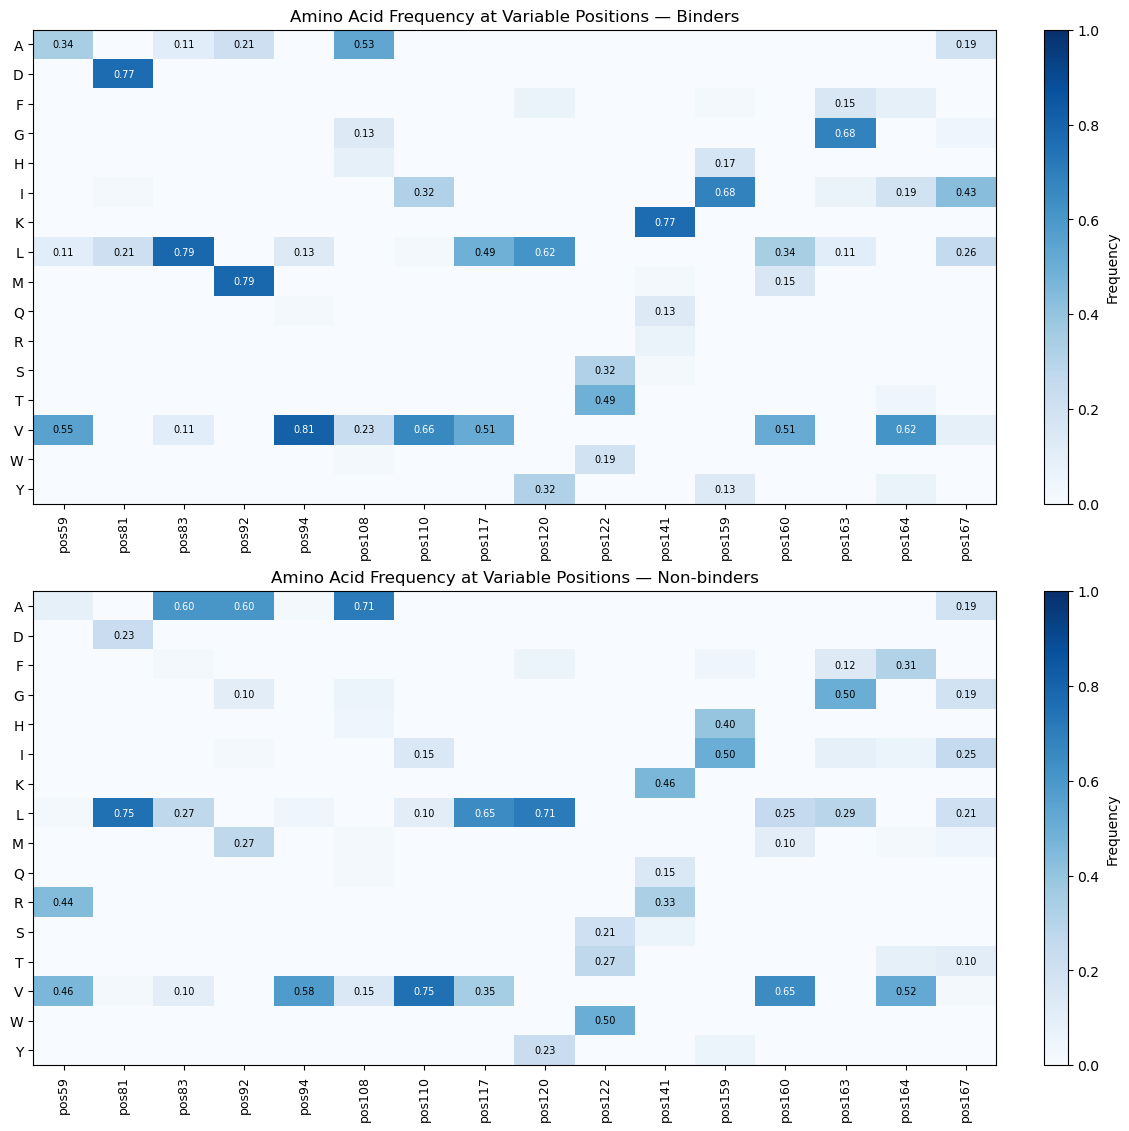


Running position-wise Fisher's exact test...

Significant positions (FDR-adjusted p < 0.05): 8

Top 20 position-AA associations:
 position amino_acid  binder_count  nonbinder_count  binder_freq  nonbinder_freq         pval     padj
       59          R             0               21        0.000           0.438 5.704231e-08 0.000004
       81          D            36               11        0.766           0.229 1.728917e-07 0.000004
       81          L            10               36        0.213           0.750 1.674700e-07 0.000004
       92          M            37               13        0.787           0.271 5.193145e-07 0.000006
       83          A             5               29        0.106           0.604 3.983955e-07 0.000006
       83          L            37               13        0.787           0.271 5.193145e-07 0.000006
       92          A            10               29        0.213           0.604 1.492700e-04 0.001471
       94          E             2            

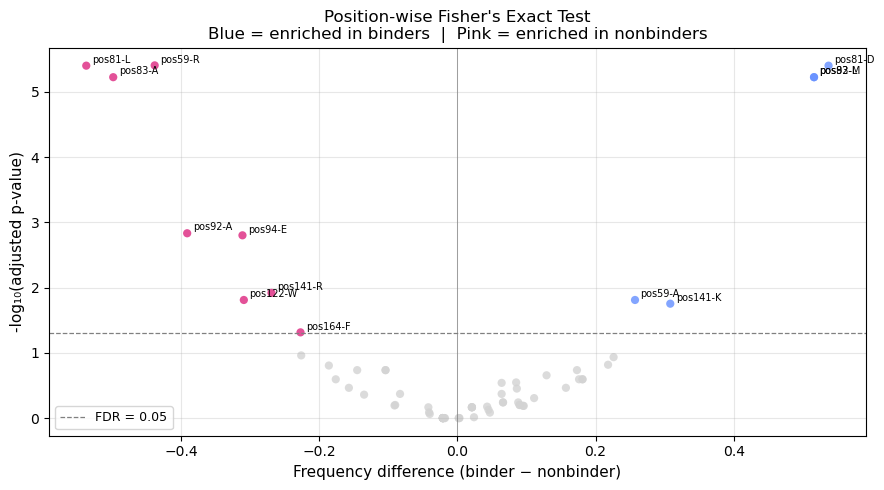


Amino acids retained after filtering: 16 / 20
  ['A', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'R', 'S', 'T', 'V', 'W', 'Y']


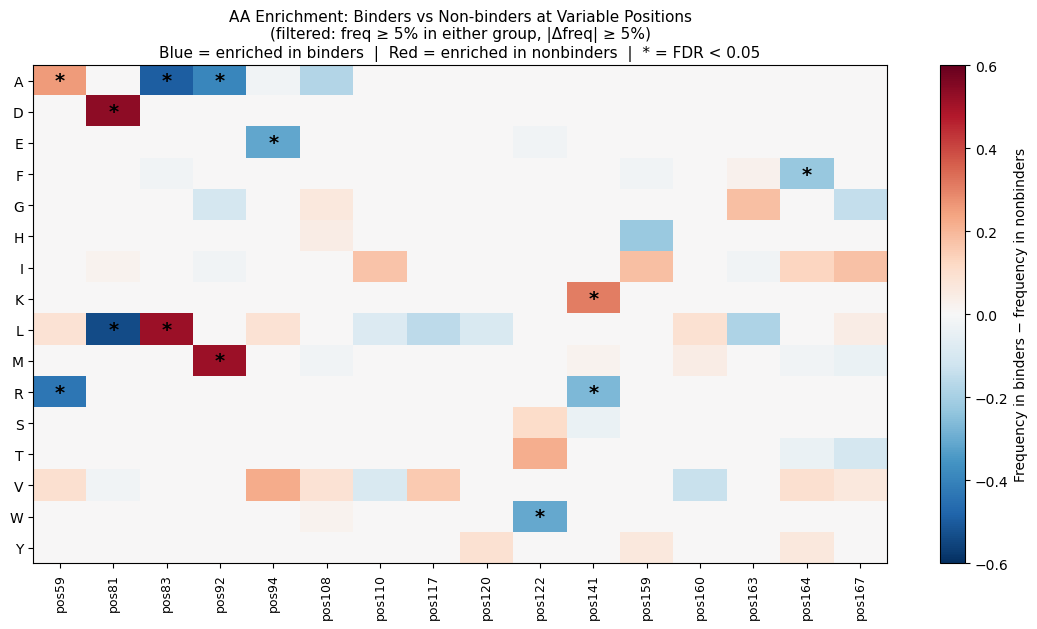


Sequence Similarity Analysis Summary
  Sequences analysed     : 95
  Variable positions     : 16
  Binders                : 47
  Non-binders            : 48

  Significant positions (FDR<0.05): 8
  Top enriched in binders:
    pos81-D: binder=0.77, nonbinder=0.23, padj=3.977e-06
    pos92-M: binder=0.79, nonbinder=0.27, padj=5.972e-06
    pos83-L: binder=0.79, nonbinder=0.27, padj=5.972e-06
    pos59-A: binder=0.34, nonbinder=0.08, padj=1.549e-02
    pos141-K: binder=0.77, nonbinder=0.46, padj=1.766e-02

Outputs written to: /Users/ivanatang/Developer/biosensors/sequence_similarity/ngs_observed


In [4]:
# ── 1. Load data ──────────────────────────────────────────────────────────────
df        = load_feat_table(FEAT_TABLE)
sequences = df["sequence"].tolist()
groups    = df["group"].tolist()
seq_ids   = df["name"].tolist() if "name" in df.columns else [f"seq{i}" for i in range(len(df))]
y         = np.array([BINARY_LABEL[g] for g in groups])
is_binder = np.array(groups) == "binder"

var_pos = variable_positions(sequences)
print(f"Variable positions ({len(var_pos)} total): {[p+1 for p in var_pos]}")

# Subsequences containing only variable positions
# Used for distance/similarity matrices so conserved scaffold positions
# don't dilute the signal from the designed residues
var_sequences = ["".join(seq[p] for p in var_pos) for seq in sequences]
print(f"Variable-position subsequence length: {len(var_sequences[0])} residues")

# ── 2. Per-position amino acid frequency table ────────────────────────────────
binder_seqs    = [seq for seq, g in zip(sequences, groups) if g == "binder"]
nonbinder_seqs = [seq for seq, g in zip(sequences, groups) if g != "binder"]

rows = []
for pos in var_pos:
    for aa in AA_ORDER:
        b_freq  = sum(seq[pos].upper() == aa for seq in binder_seqs)    / len(binder_seqs)
        nb_freq = sum(seq[pos].upper() == aa for seq in nonbinder_seqs) / len(nonbinder_seqs)
        if b_freq > 0 or nb_freq > 0:
            rows.append({
                "position":      pos + 1,
                "amino_acid":    aa,
                "binder_freq":   round(b_freq,  3),
                "nonbinder_freq": round(nb_freq, 3),
                "binder_count":  round(b_freq  * len(binder_seqs)),
                "nonbinder_count": round(nb_freq * len(nonbinder_seqs)),
            })

freq_df = pd.DataFrame(rows)

# Flag positions where one AA dominates (≥80%) in binders
conserved = freq_df[(freq_df["binder_freq"] >= 0.80)].copy()
print("Positions where a single AA appears in ≥80% of binders:")
print(conserved[["position","amino_acid","binder_freq",
                 "nonbinder_freq"]].to_string(index=False))
freq_df.to_csv(os.path.join(OUT_DIR, "aa_frequencies.csv"), index=False)

# ── 3. Frequency heatmap: binders only ────────────────────────────────────────
# Pivot to (AA x position) frequency matrix for binders
binder_pivot = freq_df.pivot(index="amino_acid", columns="position",
                              values="binder_freq").fillna(0)

# Keep only AAs that appear in at least one position at ≥5%
keep_aa = binder_pivot.index[binder_pivot.max(axis=1) >= 0.05].tolist()
binder_pivot = binder_pivot.loc[keep_aa]

fig, axes = plt.subplots(2, 1, figsize=(max(10, len(var_pos) * 0.7),
                                        max(4, len(keep_aa) * 0.35) * 2),
                         constrained_layout=True)

for ax, (grp_label, pivot_data) in zip(axes, [
    ("Binders",     freq_df.pivot(index="amino_acid", columns="position",
                                  values="binder_freq").fillna(0).loc[keep_aa]),
    ("Non-binders", freq_df.pivot(index="amino_acid", columns="position",
                                  values="nonbinder_freq").fillna(0).loc[keep_aa]),
]):
    im = ax.imshow(pivot_data.values, cmap="Blues", vmin=0, vmax=1,
                   aspect="auto", interpolation="nearest")
    ax.set_yticks(range(len(keep_aa)))
    ax.set_yticklabels(keep_aa, fontsize=10)
    ax.set_xticks(range(len(var_pos)))
    ax.set_xticklabels([f"pos{p+1}" for p in var_pos], rotation=90, fontsize=9)
    plt.colorbar(im, ax=ax, label="Frequency")

    # Annotate each cell with the frequency value if ≥ 0.10
    for row_i, aa in enumerate(keep_aa):
        for col_i, pos in enumerate(var_pos):
            val = pivot_data.iloc[row_i, col_i]
            if val >= 0.10:
                ax.text(col_i, row_i, f"{val:.2f}", ha="center", va="center",
                        fontsize=7,
                        color="white" if val > 0.6 else "black")

    ax.set_title(f"Amino Acid Frequency at Variable Positions — {grp_label}",
                 fontsize=12)

fig.savefig(os.path.join(OUT_DIR, "aa_frequency_heatmap.png"), dpi=150)
plt.show()

# ── 4. Position-wise Fisher's exact test ──────────────────────────────────────
print("\nRunning position-wise Fisher's exact test...")
fisher_df = position_fisher_test(sequences, groups, var_pos)

sig = fisher_df[fisher_df["padj"] < 0.05]
print(f"\nSignificant positions (FDR-adjusted p < 0.05): {sig['position'].nunique()}")
print("\nTop 20 position-AA associations:")
print(fisher_df.head(20).to_string(index=False))
fisher_df.to_csv(os.path.join(OUT_DIR, "fisher_test_results.csv"), index=False)

# Volcano plot
freq_diff = fisher_df["binder_freq"] - fisher_df["nonbinder_freq"]
log_padj  = -np.log10(fisher_df["padj"].clip(lower=1e-10))

fig, ax = plt.subplots(figsize=(9, 5))
colors = np.where(fisher_df["padj"] < 0.05,
                  np.where(freq_diff > 0, "#648FFF", "#DC267F"),
                  "lightgray")
ax.scatter(freq_diff, log_padj, c=colors, s=35, alpha=0.8, edgecolors="none")
ax.axhline(-np.log10(0.05), color="gray", ls="--", lw=0.9, label="FDR = 0.05")
ax.axvline(0, color="gray", ls="-", lw=0.5)
for _, row in fisher_df[fisher_df["padj"] < 0.05].iterrows():
    diff = row["binder_freq"] - row["nonbinder_freq"]
    ax.annotate(f"pos{int(row['position'])}-{row['amino_acid']}",
                xy=(diff, -np.log10(row["padj"])),
                xytext=(4, 2), textcoords="offset points", fontsize=7)
ax.set_xlabel("Frequency difference (binder − nonbinder)", fontsize=11)
ax.set_ylabel("-log₁₀(adjusted p-value)", fontsize=11)
ax.set_title("Position-wise Fisher's Exact Test\n"
             "Blue = enriched in binders  |  Pink = enriched in nonbinders",
             fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "fisher_volcano.png"), dpi=150)
plt.show()

# ── 5. Enrichment heatmap (filtered) ─────────────────────────────────────────
binder_seqs    = [seq for seq, g in zip(sequences, groups) if g == "binder"]
nonbinder_seqs = [seq for seq, g in zip(sequences, groups) if g != "binder"]

pwm_binders    = build_pwm(binder_seqs,    var_pos)
pwm_nonbinders = build_pwm(nonbinder_seqs, var_pos)
diff_mat       = (pwm_binders - pwm_nonbinders).T   # (20 AAs, n_var_pos)

# ── Filter parameters (adjust as needed) ──────────────────────────────────────
MIN_FREQ      = 0.05   # AA must appear in ≥5% of sequences in at least one group
MIN_FREQ_DIFF = 0.05   # |binder_freq - nonbinder_freq| must be ≥5% somewhere

keep_aa = [aa for aa in AA_ORDER
           if (pwm_binders[aa].max() >= MIN_FREQ
               or pwm_nonbinders[aa].max() >= MIN_FREQ)
           and diff_mat.loc[aa].abs().max() >= MIN_FREQ_DIFF]

print(f"\nAmino acids retained after filtering: {len(keep_aa)} / 20")
print(f"  {keep_aa}")

diff_filtered = diff_mat.loc[keep_aa]

fig, ax = plt.subplots(figsize=(max(10, len(var_pos) * 0.7),
                                max(4,  len(keep_aa)  * 0.4)))
im = ax.imshow(diff_filtered.values, cmap="RdBu_r", vmin=-0.6, vmax=0.6,
               aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(keep_aa)))
ax.set_yticklabels(keep_aa, fontsize=10)
ax.set_xticks(range(len(var_pos)))
ax.set_xticklabels([f"pos{p+1}" for p in var_pos], rotation=90, fontsize=9)
plt.colorbar(im, ax=ax,
             label="Frequency in binders − frequency in nonbinders")

# Asterisks on Fisher-significant cells
var_pos_1idx = list(var_pos + 1)
for _, row in fisher_df[fisher_df["padj"] < 0.05].iterrows():
    aa  = row["amino_acid"]
    pos = int(row["position"])
    if aa not in keep_aa or pos not in var_pos_1idx:
        continue
    ax.text(var_pos_1idx.index(pos), keep_aa.index(aa),
            "*", ha="center", va="center",
            fontsize=14, color="black", fontweight="bold")

ax.set_title(
    "AA Enrichment: Binders vs Non-binders at Variable Positions\n"
    f"(filtered: freq ≥ {MIN_FREQ:.0%} in either group, "
    f"|Δfreq| ≥ {MIN_FREQ_DIFF:.0%})\n"
    "Blue = enriched in binders  |  Red = enriched in nonbinders  "
    "|  * = FDR < 0.05",
    fontsize=11,
)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "enrichment_heatmap_filtered.png"), dpi=150)
plt.show()

# ── 6. Summary ────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("Sequence Similarity Analysis Summary")
print("="*55)
print(f"  Sequences analysed     : {len(sequences)}")
print(f"  Variable positions     : {len(var_pos)}")
print(f"  Binders                : {is_binder.sum()}")
print(f"  Non-binders            : {(~is_binder).sum()}")
# print(f"\n  Mean binder-binder Hamming     : {D_hamming[np.ix_(is_binder,  is_binder)].mean():.4f}")
# print(f"  Mean cross-group Hamming       : {D_hamming[np.ix_(is_binder, ~is_binder)].mean():.4f}")
# print(f"  Mean binder-binder BLOSUM62    : {S_blosum[np.ix_(is_binder,  is_binder)].mean():.4f}")
# print(f"  Mean cross-group BLOSUM62      : {S_blosum[np.ix_(is_binder, ~is_binder)].mean():.4f}")
print(f"\n  Significant positions (FDR<0.05): {sig['position'].nunique()}")
if len(sig) > 0:
    print(f"  Top enriched in binders:")
    top_b = sig[sig["binder_freq"] > sig["nonbinder_freq"]].head(5)
    for _, r in top_b.iterrows():
        print(f"    pos{int(r['position'])}-{r['amino_acid']}: "
              f"binder={r['binder_freq']:.2f}, nonbinder={r['nonbinder_freq']:.2f}, "
              f"padj={r['padj']:.3e}")
print(f"\nOutputs written to: {OUT_DIR}")


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# seq_XX motif analysis
# Checks whether seq_XX binders carry the same amino acid pattern as
# pair_3XXX binders at the key discriminating positions, or whether they
# look like nonbinders — which determines if the motif is batch-driven
# or genuinely associated with binding.
# ══════════════════════════════════════════════════════════════════════════════

import re

# ── Key discriminating positions (1-indexed, from frequency analysis) ─────────
# Binder-enriched: pos81(D), pos83(L), pos92(M), pos141(K), pos159(I), pos163(G)
# Nonbinder-enriched: pos81(L), pos122(W)
KEY_POSITIONS = [81, 83, 92, 122, 141, 159, 163]   # 1-indexed

# ── Split sequences into four subgroups ───────────────────────────────────────
is_seq  = np.array([bool(re.match(r'^seq\d+', s)) for s in seq_ids])
is_pair = ~is_seq

subgroups = {
    "seq_XX binders":    np.where( is_seq  & is_binder)[0],
    "seq_XX nonbinders": np.where( is_seq  & ~is_binder)[0],
    "pair binders":      np.where( is_pair & is_binder)[0],
    "pair nonbinders":   np.where( is_pair & ~is_binder)[0],
}
for label, idx in subgroups.items():
    print(f"{label:<22}: n = {len(idx)}")

n_seqxx = len(subgroups["seq_XX binders"]) + len(subgroups["seq_XX nonbinders"])
if n_seqxx == 0:
    print("\nNo seq_XX (legacy) sequences in this cohort — batch-confound check "
          "not applicable (SEQ_SOURCE='ngs_observed' excludes legacy seq_XX "
          "sequences entirely, since they predate md_candidate_guide.csv and "
          "have no confirmed provenance).")
else:
    # ── Per-sequence AA table for seq_XX at key positions ─────────────────────
    print("\n── Amino acids at key positions for seq_XX sequences ──")
    header_cols = [f"pos{p}" for p in KEY_POSITIONS]
    rows = []
    for idx in np.concatenate([subgroups["seq_XX binders"],
                                subgroups["seq_XX nonbinders"]]):
        row = {
            "name":  seq_ids[idx],
            "group": groups[idx],
        }
        for pos in KEY_POSITIONS:
            row[f"pos{pos}"] = sequences[idx][pos - 1].upper()
        rows.append(row)

    seq_table = pd.DataFrame(rows).set_index("name")
    print(seq_table.to_string())

    # ── Frequency comparison across all four subgroups ────────────────────────
    print("\n── AA frequency at key positions across all subgroups ──")

    # For each key position, count how often each AA appears in each subgroup
    freq_rows = []
    for pos in KEY_POSITIONS:
        aas_at_pos = set(sequences[i][pos-1].upper()
                         for i in range(len(sequences)))
        for aa in sorted(aas_at_pos):
            row = {"position": pos, "amino_acid": aa}
            for label, idx in subgroups.items():
                if len(idx) == 0:
                    row[label] = "n/a (0)"
                    continue
                count = sum(sequences[i][pos-1].upper() == aa for i in idx)
                row[label] = f"{count}/{len(idx)} ({count/len(idx)*100:.0f}%)"
            freq_rows.append(row)

    freq_comp = pd.DataFrame(freq_rows)
    print(freq_comp.to_string(index=False))

    # ── Visual: heatmap of AA at key positions, one row per seq_XX sequence ───
    # Colour by whether each residue matches the binder motif, nonbinder motif,
    # or is ambiguous
    BINDER_MOTIF    = {81: "D", 83: "L", 92: "M", 141: "K", 159: "I", 163: "G"}
    NONBINDER_MOTIF = {81: "L", 122: "W"}

    all_seq_idx = np.concatenate([subgroups["seq_XX binders"],
                                   subgroups["seq_XX nonbinders"]])
    n_seqs = len(all_seq_idx)
    n_pos  = len(KEY_POSITIONS)

    # Build colour matrix: 0=binder motif, 1=nonbinder motif, 0.5=neither
    color_mat = np.full((n_seqs, n_pos), 0.5)
    aa_labels = np.full((n_seqs, n_pos), "", dtype=object)

    for row_i, seq_i in enumerate(all_seq_idx):
        for col_i, pos in enumerate(KEY_POSITIONS):
            aa = sequences[seq_i][pos - 1].upper()
            aa_labels[row_i, col_i] = aa
            if aa == BINDER_MOTIF.get(pos):
                color_mat[row_i, col_i] = 0.0   # binder motif → blue
            elif aa == NONBINDER_MOTIF.get(pos):
                color_mat[row_i, col_i] = 1.0   # nonbinder motif → red

    row_labels = [f"{seq_ids[i]}  ({groups[i]})" for i in all_seq_idx]
    divider    = len(subgroups["seq_XX binders"])   # line between binders/nonbinders

    fig, ax = plt.subplots(figsize=(len(KEY_POSITIONS) * 1.1 + 2,
                                     n_seqs * 0.55 + 1.5))
    im = ax.imshow(color_mat, cmap="RdBu", vmin=0, vmax=1,
                   aspect="auto", interpolation="nearest")

    # Annotate each cell with the amino acid letter
    for row_i in range(n_seqs):
        for col_i in range(n_pos):
            ax.text(col_i, row_i, aa_labels[row_i, col_i],
                    ha="center", va="center", fontsize=11, fontweight="bold",
                    color="white" if color_mat[row_i, col_i] in [0.0, 1.0]
                           else "dimgray")

    # Dividing line between binders and nonbinders
    ax.axhline(divider - 0.5, color="black", lw=2, ls="--")

    # Mark which column has a binder vs nonbinder motif AA in the header
    ax.set_xticks(range(n_pos))
    ax.set_xticklabels(
        [f"pos{p}\n(B:{BINDER_MOTIF.get(p,'?')} / NB:{NONBINDER_MOTIF.get(p,'?')})"
         for p in KEY_POSITIONS],
        fontsize=9,
    )
    ax.set_yticks(range(n_seqs))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(
        "seq_XX sequences at key discriminating positions\n"
        "Blue = binder motif AA  |  Red = nonbinder motif AA  |  "
        "White = neither\n"
        "Dashed line separates binders (above) from nonbinders (below)",
        fontsize=11,
    )

    # Legend patches
    legend_patches = [
        mpatches.Patch(color="#4393c3", label="Matches binder motif"),
        mpatches.Patch(color="#d6604d", label="Matches nonbinder motif"),
        mpatches.Patch(color="#f7f7f7", label="Neither / position not in motif"),
    ]
    ax.legend(handles=legend_patches, loc="upper right",
              bbox_to_anchor=(1.0, -0.12), fontsize=9, ncol=3)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "seqXX_motif_check.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    # ── Summary verdict ───────────────────────────────────────────────────────
    print("\n── Summary: do seq_XX binders carry the pair_3XXX binder motif? ──")
    for seq_i in subgroups["seq_XX binders"]:
        matches = []
        mismatches = []
        for pos, motif_aa in BINDER_MOTIF.items():
            actual = sequences[seq_i][pos - 1].upper()
            if actual == motif_aa:
                matches.append(f"pos{pos}:{actual}✓")
            else:
                mismatches.append(f"pos{pos}:{actual}≠{motif_aa}")
        print(f"  {seq_ids[seq_i]:<20} "
              f"match={len(matches)}/6  "
              f"| agree: {', '.join(matches) if matches else 'none'}  "
              f"| differ: {', '.join(mismatches) if mismatches else 'none'}")


seq_XX binders        : n = 0
seq_XX nonbinders     : n = 0
pair binders          : n = 47
pair nonbinders       : n = 48

No seq_XX (legacy) sequences in this cohort — batch-confound check not applicable (SEQ_SOURCE='ngs_observed' excludes legacy seq_XX sequences entirely, since they predate md_candidate_guide.csv and have no confirmed provenance).


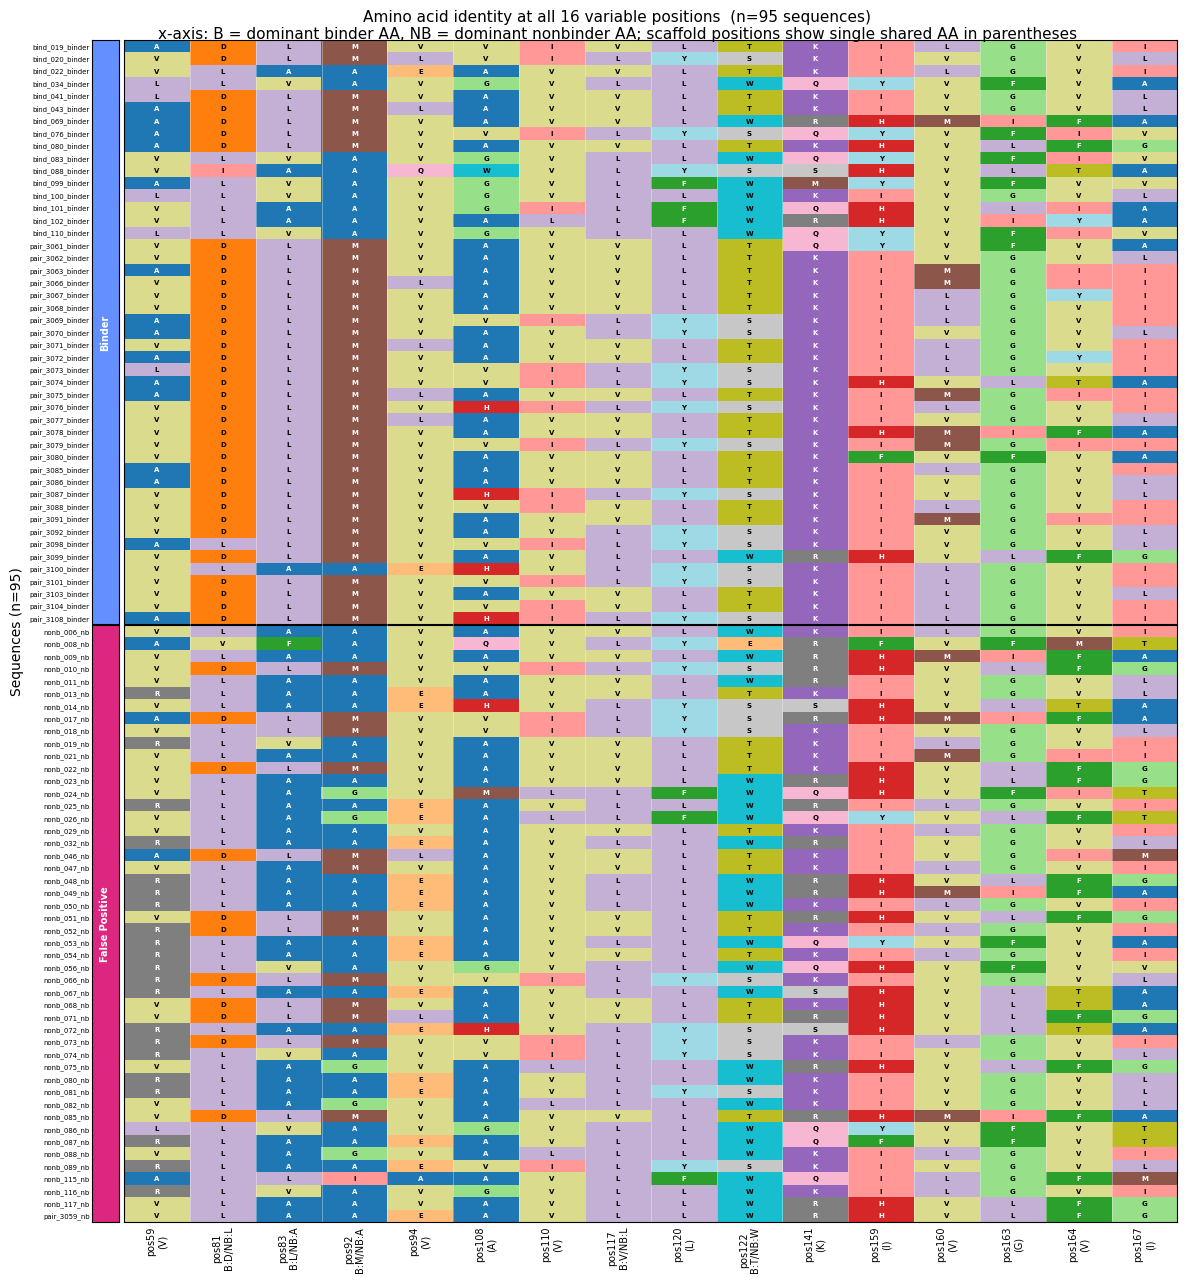

Discriminating positions (5): [np.int64(81), np.int64(83), np.int64(92), np.int64(117), np.int64(122)]
Scaffold positions       (11): [np.int64(59), np.int64(94), np.int64(108), np.int64(110), np.int64(120), np.int64(141), np.int64(159), np.int64(160), np.int64(163), np.int64(164), np.int64(167)]
Saved → /Users/ivanatang/Developer/biosensors/sequence_similarity/ngs_observed/aa_frequency_by_group.csv
Shape : 64 rows × 20 columns
        (16 positions × 4 groups = 64 rows; 17 amino acid columns)

Discriminating positions only — first 3 shown:
                            A     D    F     G    I     L     M     V
position group                                                       
81       Binder           0.0  76.6  0.0   0.0  2.1  21.3   0.0   0.0
         False Positive   0.0  22.9  0.0   0.0  0.0  75.0   0.0   2.1
         Low Confidence   0.0   0.0  0.0   0.0  0.0   0.0   0.0   0.0
         Fail Geometry    0.0   0.0  0.0   0.0  0.0   0.0   0.0   0.0
83       Binder          10.6   0

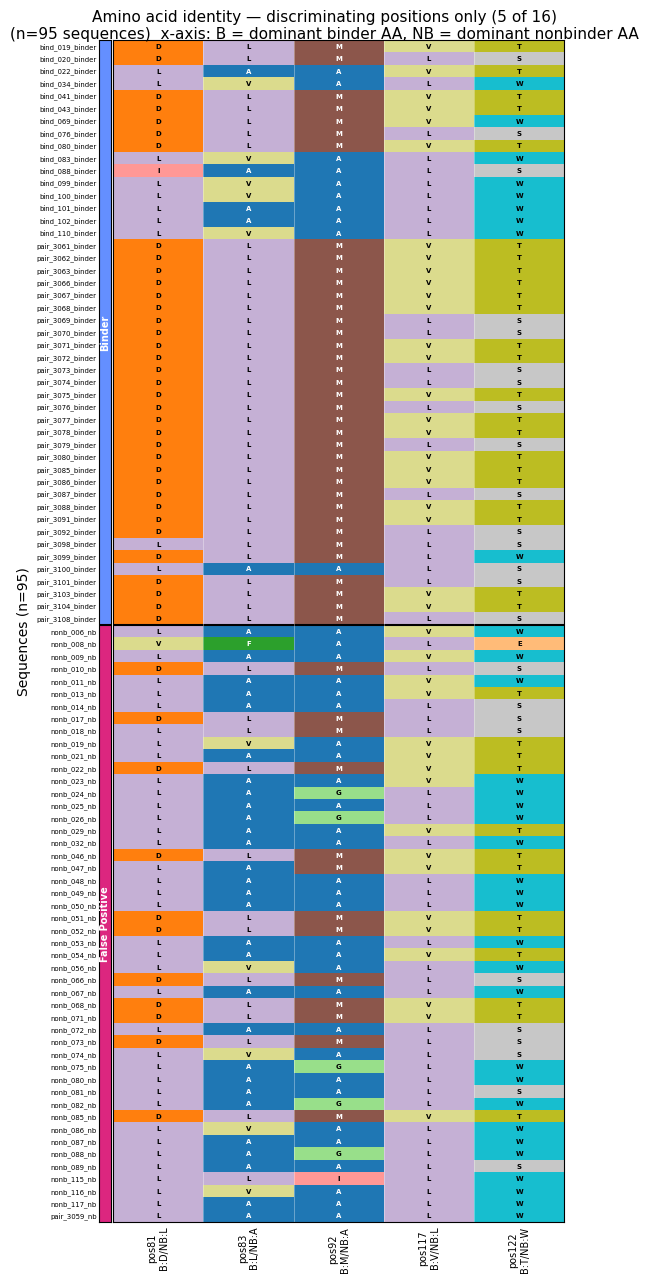

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Conserved motif summary — all 130 sequences × 24 variable positions
# Each unique amino acid has its own colour; group strip annotates rows
# ══════════════════════════════════════════════════════════════════════════════

# ── Unique colour per amino acid (tab20 gives 20 perceptually distinct colours)
AA_COLORS = {aa: plt.cm.tab20(i / 20) for i, aa in enumerate(AA_ORDER)}
AA_COLORS["X"] = (0.85, 0.85, 0.85, 1.0)   # unknown → light grey

def text_color(rgba):
    """Black or white text depending on background luminance."""
    r, g, b = rgba[:3]
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if lum < 0.55 else "black"

# ── Compute dominant AA per group per position ────────────────────────────────
b_seqs  = [sequences[i] for i in range(len(sequences)) if groups[i] == "binder"]
nb_seqs = [sequences[i] for i in range(len(sequences)) if groups[i] != "binder"]

dominant_b, dominant_nb = {}, {}
for pos in var_pos:
    b_counts  = {}
    nb_counts = {}
    for seq in b_seqs:
        aa = seq[pos].upper()
        b_counts[aa]  = b_counts.get(aa,  0) + 1
    for seq in nb_seqs:
        aa = seq[pos].upper()
        nb_counts[aa] = nb_counts.get(aa, 0) + 1
    dominant_b[pos]  = max(b_counts,  key=b_counts.get)
    dominant_nb[pos] = max(nb_counts, key=nb_counts.get)

is_scaffold = {pos: dominant_b[pos] == dominant_nb[pos] for pos in var_pos}

# ── Sort sequences: binders first, then nonbinder subgroups ──────────────────
GROUP_ORDER = ["binder", "nonbinder", "low_pkt", "fail_gate"]
sorted_idx  = sorted(range(len(sequences)),
                     key=lambda i: ({g: k for k, g in enumerate(GROUP_ORDER)}
                                    .get(groups[i], 99), seq_ids[i]))
grp_sorted  = [groups[i] for i in sorted_idx]
n_seqs = len(sorted_idx)
n_pos  = len(var_pos)

# ── Build RGBA colour array for imshow ───────────────────────────────────────
color_array = np.ones((n_seqs, n_pos, 4))   # default white
aa_grid     = np.empty((n_seqs, n_pos), dtype=object)

for row_i, seq_i in enumerate(sorted_idx):
    for col_i, pos in enumerate(var_pos):
        aa = sequences[seq_i][pos].upper()
        aa_grid[row_i, col_i]    = aa
        color_array[row_i, col_i] = AA_COLORS.get(aa, AA_COLORS["X"])

# ── Group boundaries (rows where group changes) ───────────────────────────────
# imshow origin='upper': row i sits at data-y = i, ylim = (n-0.5, -0.5)
# boundary between row k-1 and row k is at data-y = k - 0.5
boundaries = [k - 0.5 for k in range(1, n_seqs)
              if grp_sorted[k] != grp_sorted[k - 1]]

# ── Figure ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(max(14, n_pos * 0.55 + 3),
                           max(10, n_seqs * 0.13 + 3)))
gs  = fig.add_gridspec(1, 2, width_ratios=[0.025, 1], wspace=0.01)
ax_strip = fig.add_subplot(gs[0, 0])
ax_grid  = fig.add_subplot(gs[0, 1])

# ── Residue grid ──────────────────────────────────────────────────────────────
ax_grid.imshow(color_array, aspect="auto", interpolation="nearest")
# After imshow, ax_grid ylim = (n_seqs-0.5, -0.5)  [inverted, origin='upper']

for row_i in range(n_seqs):
    for col_i in range(n_pos):
        aa   = aa_grid[row_i, col_i]
        rgba = AA_COLORS.get(aa, AA_COLORS["X"])
        ax_grid.text(col_i, row_i, aa,
                     ha="center", va="center",
                     fontsize=5, fontweight="bold",
                     color=text_color(rgba))

for b in boundaries:
    ax_grid.axhline(b, color="black", lw=1.5)

# Subtle column dividers between positions
for col_i in range(n_pos - 1):
    ax_grid.axvline(col_i + 0.5, color="white", lw=0.4, alpha=0.6)

xlabels = []
for pos in var_pos:
    if is_scaffold[pos]:
        xlabels.append(f"pos{pos+1}\n({dominant_b[pos]})")
    else:
        xlabels.append(f"pos{pos+1}\nB:{dominant_b[pos]}/NB:{dominant_nb[pos]}")
ax_grid.set_xticks(range(n_pos))
ax_grid.set_xticklabels(xlabels, fontsize=7, rotation=90)
ax_grid.set_yticks([])
ax_grid.tick_params(axis="x", which="both", length=0, pad=3)

# ── Group colour strip ────────────────────────────────────────────────────────
# Match imshow y-coordinates exactly: ylim = (n_seqs-0.5, -0.5), origin='upper'
ax_strip.set_xlim(0, 1)
ax_strip.set_ylim(n_seqs - 0.5, -0.5)   # ← inverted to match imshow
ax_strip.set_xticks([])
ax_strip.set_yticks(range(n_seqs))
ax_strip.set_yticklabels([seq_ids[i] for i in sorted_idx], fontsize=5)
ax_strip.tick_params(axis="y", which="both", length=0, pad=2)
ax_strip.yaxis.set_tick_params(labelleft=True)
ax_strip.set_ylabel(f"Sequences (n={n_seqs})", fontsize=10, labelpad=4)

for i in range(n_seqs):
    ax_strip.add_patch(plt.Rectangle(
        (0, i - 0.5), 1, 1,            # y from i-0.5 to i+0.5 in data coords
        color=GROUP_COLORS.get(grp_sorted[i], "#aaaaaa"),
        transform=ax_strip.transData,
    ))

# Centred group name labels
seen = {}
for i, g in enumerate(grp_sorted):
    if g not in seen:
        seen[g] = i
for g, start_i in seen.items():
    end_i = next((j for j in range(start_i + 1, n_seqs)
                  if grp_sorted[j] != g), n_seqs)
    mid   = (start_i + end_i - 1) / 2   # centre row index
    ax_strip.text(0.5, mid, DISPLAY_LABEL.get(g, g),
                  ha="center", va="center", fontsize=7,
                  rotation=90, color="white", fontweight="bold")

for b in boundaries:
    ax_strip.axhline(b, color="black", lw=1.5)

fig.suptitle(
    f"Amino acid identity at all {n_pos} variable positions  "
    f"(n={n_seqs} sequences)\n"
    "x-axis: B = dominant binder AA, NB = dominant nonbinder AA; "
    "scaffold positions show single shared AA in parentheses",
    fontsize=11, y=0.90,
)
plt.savefig(os.path.join(OUT_DIR, "conserved_motif_summary.png"), dpi=300, bbox_inches="tight")
plt.show()

# ── Print discriminating vs scaffold positions ────────────────────────────────
disc_pos = [pos for pos in var_pos if not is_scaffold[pos]]
scaf_pos = [pos for pos in var_pos if     is_scaffold[pos]]
print(f"Discriminating positions ({len(disc_pos)}): {[p+1 for p in disc_pos]}")
print(f"Scaffold positions       ({len(scaf_pos)}): {[p+1 for p in scaf_pos]}")


# ── Per-group AA frequency table → CSV ───────────────────────────────────────
# Row index  : two levels — (position, group)
# Columns    : one per unique amino acid observed across the dataset
# Cell values: frequency (%) of that amino acid in that group at that position

all_groups = ["binder", "nonbinder", "low_pkt", "fail_gate"]
group_seqs = {g: [sequences[i] for i in range(len(sequences))
                   if groups[i] == g]
              for g in all_groups}
group_n    = {g: len(v) for g, v in group_seqs.items()}

# Amino acids that appear at least once across all variable positions
present_aas = sorted({
    sequences[i][pos].upper()
    for i in range(len(sequences))
    for pos in var_pos
    if sequences[i][pos].upper() in AA_COLORS
})

# Build rows: one per (position, group) combination
table_rows = []
for pos in var_pos:
    for g in all_groups:
        n   = group_n[g]
        row = {
            "position":   pos + 1,
            "group":      DISPLAY_LABEL[g],
            "n":          n,
            "dominant_AA": dominant_b[pos] if g == "binder" else dominant_nb[pos],
            "is_scaffold": is_scaffold[pos],
        }
        for aa in present_aas:
            count    = sum(seq[pos].upper() == aa for seq in group_seqs[g])
            row[aa]  = round(count / n * 100, 1) if n > 0 else 0.0
        table_rows.append(row)

flat = pd.DataFrame(table_rows)

# Two-level row index: (position, group)
freq_table = flat.set_index(["position", "group"])

# Save to CSV
out_path = os.path.join(OUT_DIR, "aa_frequency_by_group.csv")
freq_table.to_csv(out_path)
print(f"Saved → {out_path}")
print(f"Shape : {freq_table.shape[0]} rows × {freq_table.shape[1]} columns")
print(f"        ({len(var_pos)} positions × {len(all_groups)} groups = "
      f"{len(var_pos)*len(all_groups)} rows; "
      f"{len(present_aas)} amino acid columns)")

# Preview: discriminating positions only
disc_pos_1idx = [pos + 1 for pos in var_pos if not is_scaffold[pos]]
print(f"\nDiscriminating positions only — first 3 shown:")
preview = freq_table.loc[disc_pos_1idx[:3], present_aas]
# Drop all-zero columns for readability
preview = preview.loc[:, (preview != 0).any(axis=0)]
print(preview.to_string())

# ── Conserved motif plot — discriminating positions only ──────────────────────
disc_var_pos = [pos for pos in var_pos if not is_scaffold[pos]]
n_disc       = len(disc_var_pos)
print(f"Discriminating positions ({n_disc}): {[p+1 for p in disc_var_pos]}")

# Rebuild colour array for discriminating positions only
color_array_disc = np.ones((n_seqs, n_disc, 4))
aa_grid_disc     = np.empty((n_seqs, n_disc), dtype=object)

for row_i, seq_i in enumerate(sorted_idx):
    for col_i, pos in enumerate(disc_var_pos):
        aa = sequences[seq_i][pos].upper()
        aa_grid_disc[row_i, col_i]     = aa
        color_array_disc[row_i, col_i] = AA_COLORS.get(aa, AA_COLORS["X"])

fig2 = plt.figure(figsize=(max(6, n_disc * 0.55 + 3),
                            max(10, n_seqs * 0.13 + 3)))
gs2      = fig2.add_gridspec(1, 2, width_ratios=[0.025, 1], wspace=0.01)
ax_strip2 = fig2.add_subplot(gs2[0, 0])
ax_grid2  = fig2.add_subplot(gs2[0, 1])

# ── Residue grid ──────────────────────────────────────────────────────────────
ax_grid2.imshow(color_array_disc, aspect="auto", interpolation="nearest")

for row_i in range(n_seqs):
    for col_i in range(n_disc):
        aa   = aa_grid_disc[row_i, col_i]
        rgba = AA_COLORS.get(aa, AA_COLORS["X"])
        ax_grid2.text(col_i, row_i, aa,
                      ha="center", va="center",
                      fontsize=5, fontweight="bold",
                      color=text_color(rgba))

for b in boundaries:
    ax_grid2.axhline(b, color="black", lw=1.5)
for col_i in range(n_disc - 1):
    ax_grid2.axvline(col_i + 0.5, color="white", lw=0.4, alpha=0.6)

xlabels2 = [f"pos{pos+1}\nB:{dominant_b[pos]}/NB:{dominant_nb[pos]}"
            for pos in disc_var_pos]
ax_grid2.set_xticks(range(n_disc))
ax_grid2.set_xticklabels(xlabels2, fontsize=7, rotation=90)
ax_grid2.set_yticks([])
ax_grid2.tick_params(axis="x", which="both", length=0, pad=3)

# ── Group colour strip ────────────────────────────────────────────────────────
ax_strip2.set_xlim(0, 1)
ax_strip2.set_ylim(n_seqs - 0.5, -0.5)
ax_strip2.set_xticks([])
ax_strip2.set_yticks(range(n_seqs))
ax_strip2.set_yticklabels([seq_ids[i] for i in sorted_idx], fontsize=5)
ax_strip2.tick_params(axis="y", which="both", length=0, pad=2)
ax_strip2.yaxis.set_tick_params(labelleft=True)
ax_strip2.set_ylabel(f"Sequences (n={n_seqs})", fontsize=10, labelpad=4)

for i in range(n_seqs):
    ax_strip2.add_patch(plt.Rectangle(
        (0, i - 0.5), 1, 1,
        color=GROUP_COLORS.get(grp_sorted[i], "#aaaaaa"),
        transform=ax_strip2.transData,
    ))

seen2 = {}
for i, g in enumerate(grp_sorted):
    if g not in seen2:
        seen2[g] = i
for g, start_i in seen2.items():
    end_i = next((j for j in range(start_i + 1, n_seqs)
                  if grp_sorted[j] != g), n_seqs)
    mid   = (start_i + end_i - 1) / 2
    ax_strip2.text(0.5, mid, DISPLAY_LABEL.get(g, g),
                   ha="center", va="center", fontsize=7,
                   rotation=90, color="white", fontweight="bold")

for b in boundaries:
    ax_strip2.axhline(b, color="black", lw=1.5)

fig2.suptitle(
    f"Amino acid identity — discriminating positions only ({n_disc} of {n_pos})\n"
    f"(n={n_seqs} sequences)  "
    "x-axis: B = dominant binder AA, NB = dominant nonbinder AA",
    fontsize=11, y=0.90,
)
plt.savefig(os.path.join(OUT_DIR, "conserved_motif_discriminating.png"), dpi=300, bbox_inches="tight")
plt.show()


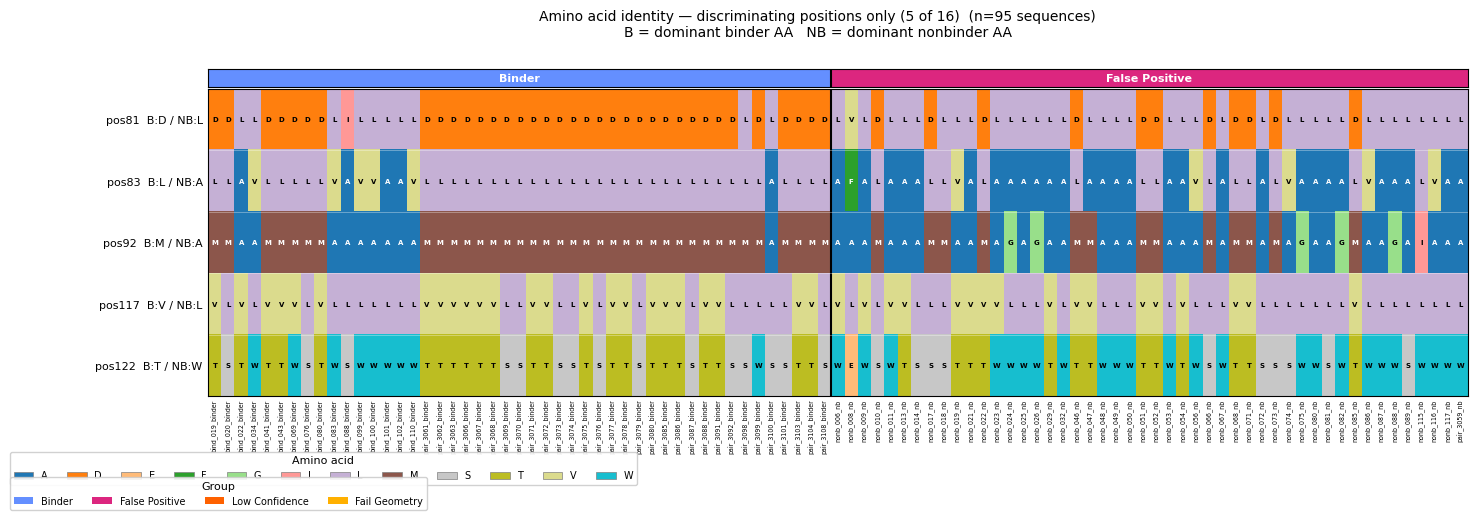

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Wide version of discriminating motif plot — slide-friendly layout
# Transposed: sequences along x-axis (columns), positions along y-axis (rows)
# ══════════════════════════════════════════════════════════════════════════════

# disc_var_pos, sorted_idx, grp_sorted, AA_COLORS, color_array_disc,
# aa_grid_disc, boundaries, GROUP_COLORS, DISPLAY_LABEL all from previous cell

# ── Transpose colour and AA arrays: (n_seqs, n_disc) → (n_disc, n_seqs) ──────
color_wide = color_array_disc.transpose(1, 0, 2)   # (n_disc, n_seqs, 4)
aa_wide    = aa_grid_disc.T                         # (n_disc, n_seqs)

# Vertical group boundaries: between sequences (now columns)
v_boundaries = [k - 0.5 for k in range(1, n_seqs)
                if grp_sorted[k] != grp_sorted[k - 1]]

# ── Figure: top group strip + main grid ──────────────────────────────────────
fig_w = plt.figure(figsize=(max(16, n_seqs * 0.15 + 2),
                             max(4,  n_disc * 0.45 + 2)))
gs_w  = fig_w.add_gridspec(2, 1, height_ratios=[0.06, 1], hspace=0.01)
ax_top  = fig_w.add_subplot(gs_w[0, 0])   # group colour strip
ax_main = fig_w.add_subplot(gs_w[1, 0])   # residue grid

# ── Residue grid (transposed) ─────────────────────────────────────────────────
ax_main.imshow(color_wide, aspect="auto", interpolation="nearest")
# imshow origin='upper': row 0 at top → position 0 at top, seq 0 at left

for row_i in range(n_disc):
    for col_i in range(n_seqs):
        aa   = aa_wide[row_i, col_i]
        rgba = AA_COLORS.get(aa, AA_COLORS["X"])
        ax_main.text(col_i, row_i, aa,
                     ha="center", va="center",
                     fontsize=5, fontweight="bold",
                     color=text_color(rgba))

# Vertical group dividers
for b in v_boundaries:
    ax_main.axvline(b, color="black", lw=1.5)

# Subtle horizontal dividers between positions
for row_i in range(n_disc - 1):
    ax_main.axhline(row_i + 0.5, color="white", lw=0.4, alpha=0.6)

# y-axis: position labels
ylabels = [f"pos{pos+1}  B:{dominant_b[pos]} / NB:{dominant_nb[pos]}"
           for pos in disc_var_pos]
ax_main.set_yticks(range(n_disc))
ax_main.set_yticklabels(ylabels, fontsize=8)
ax_main.tick_params(axis="y", which="both", length=0, pad=4)

# x-axis: sequence IDs (small, rotated)
ax_main.set_xticks(range(n_seqs))
ax_main.set_xticklabels([seq_ids[i] for i in sorted_idx],
                         fontsize=4.5, rotation=90)
ax_main.tick_params(axis="x", which="both", length=0, pad=2)

# ── Top group colour strip ────────────────────────────────────────────────────
# Match imshow x-coords: xlim = (-0.5, n_seqs-0.5)
ax_top.set_xlim(-0.5, n_seqs - 0.5)
ax_top.set_ylim(0, 1)
ax_top.set_xticks([])
ax_top.set_yticks([])

for i in range(n_seqs):
    ax_top.add_patch(plt.Rectangle(
        (i - 0.5, 0), 1, 1,
        color=GROUP_COLORS.get(grp_sorted[i], "#aaaaaa"),
        transform=ax_top.transData,
    ))

# Group name labels centred within each block
seen_w = {}
for i, g in enumerate(grp_sorted):
    if g not in seen_w:
        seen_w[g] = i
for g, start_i in seen_w.items():
    end_i = next((j for j in range(start_i + 1, n_seqs)
                  if grp_sorted[j] != g), n_seqs)
    mid   = (start_i + end_i - 1) / 2
    ax_top.text(mid, 0.5, DISPLAY_LABEL.get(g, g),
                ha="center", va="center",
                fontsize=8, color="white", fontweight="bold")

# Vertical dividers on strip
for b in v_boundaries:
    ax_top.axvline(b, color="black", lw=1.5)

# ── Legends ───────────────────────────────────────────────────────────────────
present_aas_w = sorted({aa_wide[r, c]
                         for r in range(n_disc) for c in range(n_seqs)})
aa_handles_w  = [
    mpatches.Patch(facecolor=AA_COLORS[aa][:3], label=aa,
                   edgecolor="grey", linewidth=0.5)
    for aa in present_aas_w
]
grp_handles_w = [
    mpatches.Patch(facecolor=GROUP_COLORS[g], label=DISPLAY_LABEL[g])
    for g in GROUP_ORDER if g in GROUP_COLORS
]
fig_w.legend(handles=aa_handles_w, title="Amino acid",
             loc="upper left",
             bbox_to_anchor=(0.0, -0.01),
             bbox_transform=fig_w.transFigure,
             fontsize=7, ncol=min(len(present_aas_w), 12),
             framealpha=0.9, title_fontsize=8)
fig_w.legend(handles=grp_handles_w, title="Group",
             loc="upper left",
             bbox_to_anchor=(0.0, -0.07),
             bbox_transform=fig_w.transFigure,
             fontsize=7, ncol=len(grp_handles_w),
             framealpha=0.9, title_fontsize=8)

fig_w.suptitle(
    f"Amino acid identity — discriminating positions only ({n_disc} of {n_pos})  "
    f"(n={n_seqs} sequences)\n"
    "B = dominant binder AA   NB = dominant nonbinder AA",
    fontsize=10, y=1.02,
)
plt.savefig(os.path.join(OUT_DIR, "conserved_motif_discriminating_wide.png"),
            dpi=300, bbox_inches="tight")
plt.show()
